<a href="https://colab.research.google.com/github/LennyAmsterdam1717/XAI-Project-1/blob/main/XAI_PROJECT_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision tensorboard torchmetrics captum quantus

In [ ]:
import time, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")

PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
CUDA        : True


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashery/chexpert")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chexpert' dataset.
Path to dataset files: /kaggle/input/chexpert


In [ ]:
import os
import pandas as pd

# Using the path from the successful kagglehub download in the first cell
# path = '/kaggle/input/chexpert'
train_csv_path = os.path.join(path, 'train.csv')

# 1. Load the Metadata
df = pd.read_csv(train_csv_path)

# --- MANDATORY PREPROCESSING STEPS ---

# Select only Frontal chest X-ray images
df = df[df['Frontal/Lateral'] == 'Frontal']

# Target "Pleural Effusion"
# Fill missing values with 0 and treat uncertain (-1) as 0
df['Pleural Effusion'] = df['Pleural Effusion'].replace(-1, 0).fillna(0)

print(f"Total Frontal Images to process: {len(df)}")
df.head()

Total Frontal Images to process: 191027


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,0.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,0.0,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN
5,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 191027 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        191027 non-null  object 
 1   Sex                         191027 non-null  object 
 2   Age                         191027 non-null  int64  
 3   Frontal/Lateral             191027 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  16974 non-null   float64
 6   Enlarged Cardiomediastinum  34818 non-null   float64
 7   Cardiomegaly                37961 non-null   float64
 8   Lung Opacity                103693 non-null  float64
 9   Lung Lesion                 8924 non-null    float64
 10  Edema                       77408 non-null   float64
 11  Consolidation               56972 non-null   float64
 12  Pneumonia                   22531 non-null   float64
 13  Atelectasis        

None

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Check actual folder name in the download path
# Kagglehub downloads often put the data in /kaggle/input/chexpert/...
# Let's verify if 'CheXpert-v1.0-small' is a subfolder or if the CSV needs path adjustment
print(f"Content of {path}: {os.listdir(path)}")

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Path in CSV: 'CheXpert-v1.0-small/train/...'
        # We need to make sure this exists under root_dir
        img_rel_path = self.dataframe.iloc[idx, 0]
        img_name = os.path.join(self.root_dir, img_rel_path)

        # If the folder 'CheXpert-v1.0-small' is inside another 'chexpert' folder,
        # we might need to adjust.
        if not os.path.exists(img_name):
             # Try a fallback: remove the first part of the path if it's redundant
             parts = img_rel_path.split('/', 1)
             if len(parts) > 1:
                 img_name = os.path.join(self.root_dir, parts[1])

        image = Image.open(img_name).convert('RGB')
        label = self.dataframe.iloc[idx]['Pleural Effusion']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

# 3. Initialize
# Using the directory that contains the 'train' and 'valid' folders
train_dataset = CheXpertDataset(dataframe=df, root_dir=path, transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print(f"DataLoader updated with path checking.")

Content of /kaggle/input/chexpert: ['valid.csv', 'valid', 'train.csv', 'train']
DataLoader updated with path checking.


In [ ]:
from torch.utils.data import random_split

# 1. Define split sizes (80% train, 20% validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# 2. Perform the split
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# 3. Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

# 4. Prepare the Test Set (using the original validation.csv)
valid_csv_path = os.path.join(path, 'valid.csv')
test_df = pd.read_csv(valid_csv_path)

# Apply same filtering as training (Frontal only and clean Pleural Effusion)
test_df = test_df[test_df['Frontal/Lateral'] == 'Frontal']
test_df['Pleural Effusion'] = test_df['Pleural Effusion'].replace(-1, 0).fillna(0)

test_dataset = CheXpertDataset(dataframe=test_df, root_dir=path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Dataset Splitting Complete:")
print(f"- Training images:   {len(train_subset)}")
print(f"- Validation images: {len(val_subset)}")
print(f"- Test images:       {len(test_dataset)}")

Dataset Splitting Complete:
- Training images:   152821
- Validation images: 38206
- Test images:       202


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torch

# Load pre-trained ResNet-18
model = models.resnet18(weights='IMAGENET1K_V1')

# Modify final layer for binary classification
num_ftrs = model.fc.in_features

# Option A: Use Sigmoid + BCELoss (less stable)
# model.fc = nn.Sequential(
#     nn.Linear(num_ftrs, 1),
#     nn.Sigmoid()
# )

# Option B (recommended): Use raw logits + BCEWithLogitsLoss
model.fc = nn.Linear(num_ftrs, 1)

# Freeze all layers except final layer
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Define Loss and Optimizer
# If you used raw logits (Option B)
pos = (df['Pleural Effusion'] == 1).sum()
neg = (df['Pleural Effusion'] == 0).sum()
pos_weight = torch.tensor([neg / pos]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Only train parameters that require gradients
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [ ]:
import torchmetrics

def evaluate_model(model, data_loader, device):
    model.eval()
    acc_metric = torchmetrics.Accuracy(task='binary').to(device)
    auroc_metric = torchmetrics.AUROC(task='binary').to(device)
    precision_metric = torchmetrics.Precision(task='binary').to(device)
    recall_metric = torchmetrics.Recall(task='binary').to(device)
    f1_metric = torchmetrics.F1Score(task='binary').to(device)

    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)

            acc_metric.update(probs, labels.int())
            auroc_metric.update(probs, labels.int())
            precision_metric.update(probs, labels.int())
            recall_metric.update(probs, labels.int())
            f1_metric.update(probs, labels.int())

            all_preds.append(probs.cpu())
            all_labels.append(labels.cpu())

    final_acc = acc_metric.compute()
    final_auroc = auroc_metric.compute()
    final_precision = precision_metric.compute()
    final_recall = recall_metric.compute()
    final_f1 = f1_metric.compute()

    print(f'Accuracy:  {final_acc:.4f}')
    print(f'AUC-ROC:   {final_auroc:.4f}')
    print(f'Precision: {final_precision:.4f}')
    print(f'Recall:    {final_recall:.4f}')
    print(f'F1 Score:  {final_f1:.4f}')

    return torch.cat(all_preds), torch.cat(all_labels), final_acc, final_auroc

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, acc_metric = 0.0, torchmetrics.Accuracy(task='binary').to(device)
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        probs = torch.sigmoid(outputs)
        acc_metric.update(probs, labels.int())
    return running_loss / len(dataloader.dataset), acc_metric.compute()

In [ ]:
import torch.optim as optim
from torch.optim import lr_scheduler

# Optimizer and scheduler
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

num_epochs = 3
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_auroc': []}

print(f"Starting Training Phase for {num_epochs} epochs...")

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch + 1}/{num_epochs} ---")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    exp_lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print("Validating...")
    val_preds, val_true, val_acc, val_auroc = evaluate_model(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_acc'].append(val_acc.item())
    history['val_auroc'].append(val_auroc.item())

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auroc:.4f} | LR: {current_lr}")

print("\nTraining Complete!")

# Final Evaluation on Test Set
print("Final Evaluation on Test Set...")
test_preds, test_true, test_acc, test_auroc = evaluate_model(model, test_loader, device)

Starting Training Phase for 3 epochs...

--- Epoch 1/3 ---
Validating...
Accuracy:  0.7657
AUC-ROC:   0.8502
Precision: 0.6766
Recall:    0.7993
F1 Score:  0.7329
Epoch 1 | Loss: 0.6053 | Train Acc: 0.7479 | Val Acc: 0.7657 | Val AUC: 0.8502 | LR: 0.0001

--- Epoch 2/3 ---
Validating...
Accuracy:  0.7560
AUC-ROC:   0.8523
Precision: 0.6514
Recall:    0.8456
F1 Score:  0.7359
Epoch 2 | Loss: 0.5446 | Train Acc: 0.7794 | Val Acc: 0.7560 | Val AUC: 0.8523 | LR: 0.0001

--- Epoch 3/3 ---
Validating...
Accuracy:  0.7650
AUC-ROC:   0.8401
Precision: 0.6915
Recall:    0.7498
F1 Score:  0.7195
Epoch 3 | Loss: 0.4548 | Train Acc: 0.8251 | Val Acc: 0.7650 | Val AUC: 0.8401 | LR: 0.0001

Training Complete!
Final Evaluation on Test Set...
Accuracy:  0.8465
AUC-ROC:   0.8975
Precision: 0.7797
Recall:    0.7188
F1 Score:  0.7480


In [ ]:
import torch

# Final Evaluation on Test Set
print("Running final evaluation on Test Set...")
test_preds, test_true, test_acc, test_auroc = evaluate_model(model, test_loader, device)

# Save the model weights
model_save_path = 'chexpert_model.pth'
torch.save(model.state_dict(), model_save_path)

print(f"\nModel weights saved successfully to: {model_save_path}")
print("You can now use these weights for generating explanations in the next stage.")

Running final evaluation on Test Set...
Accuracy:  0.8465
AUC-ROC:   0.8975
Precision: 0.7797
Recall:    0.7188
F1 Score:  0.7480

Model weights saved successfully to: chexpert_model.pth
You can now use these weights for generating explanations in the next stage.


In [ ]:
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate_heatmap(self, input_image):
        self.model.eval()
        output = self.model(input_image)
        self.model.zero_grad()
        output.backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.detach().cpu().numpy()

# 1. Initialize Grad-CAM
grad_cam = GradCAM(model, model.layer4[-1])

# 2. Get sample
images, labels = next(iter(test_loader))
img_tensor = images[0].unsqueeze(0).to(device)

# 3. Generate Heatmap
heatmap = grad_cam.generate_heatmap(img_tensor)

# 4. Visualization
def show_cam_on_image(img, mask):
    img_np = img.permute(1, 2, 0).cpu().numpy()
    # De-normalize
    img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    # Resize mask to match image size (224, 224)
    mask_resized = cv2.resize(mask, (img_np.shape[1], img_np.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * mask_resized), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam = heatmap + np.float32(img_np)
    cam = cam / np.max(cam)
    return np.uint8(255 * cam)

result = show_cam_on_image(images[0], heatmap)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Label: {labels[0].item()})")
plt.imshow(np.clip((images[0].permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406], 0, 1))
plt.subplot(1, 2, 2)
plt.title("Grad-CAM Explanation")
plt.imshow(result)
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['val_acc'], label='Val Accuracy', marker='o')
ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_auroc'], label='Val AUC-ROC', marker='o', color='orange')
ax2.set_title('AUC-ROC over Epochs')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from captum.attr import Saliency, LayerGradCam, LayerAttribution, GuidedBackprop

model.eval()

saliency = Saliency(model)

layer_gc = LayerGradCam(model, model.layer4[-1])

images, labels = next(iter(test_loader))

input_img = images[0].unsqueeze(0).to(device)
input_img.requires_grad = True

#saliency - pixel level
sal_attr = saliency.attribute(input_img, target=None)
sal_map = sal_attr.squeeze().cpu().detach().numpy()
sal_map = np.abs(sal_map)
sal_map = np.max(sal_map, axis=0)
sal_map /= (sal_map.max() + 1e-8)

#Grad-Cam - region level
gc_attr = layer_gc.attribute(input_img, target=None)

gc_attr_upsampled = LayerAttribution.interpolate(
    gc_attr,
    input_img.shape[2:]
)

gc_map = gc_attr_upsampled.squeeze().cpu().detach().numpy()
gc_map = np.maximum(gc_map, 0)
gc_map /= (gc_map.max() + 1e-8)

In [ ]:
from captum.attr import GuidedBackprop, LayerGradCam, LayerAttribution

model.eval()

gbp = GuidedBackprop(model)
layer_gc = LayerGradCam(model, model.layer4[-1])

images, labels = next(iter(test_loader))

input_img = images[0].unsqueeze(0).to(device)
input_img.requires_grad = True

# GuidedBackprop - pixel level
gbp_attr = gbp.attribute(input_img, target=None)
gbp_map = gbp_attr.squeeze().cpu().detach().numpy()
gbp_map = np.abs(gbp_map)
gbp_map = np.max(gbp_map, axis=0)
gbp_map /= (gbp_map.max() + 1e-8)

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


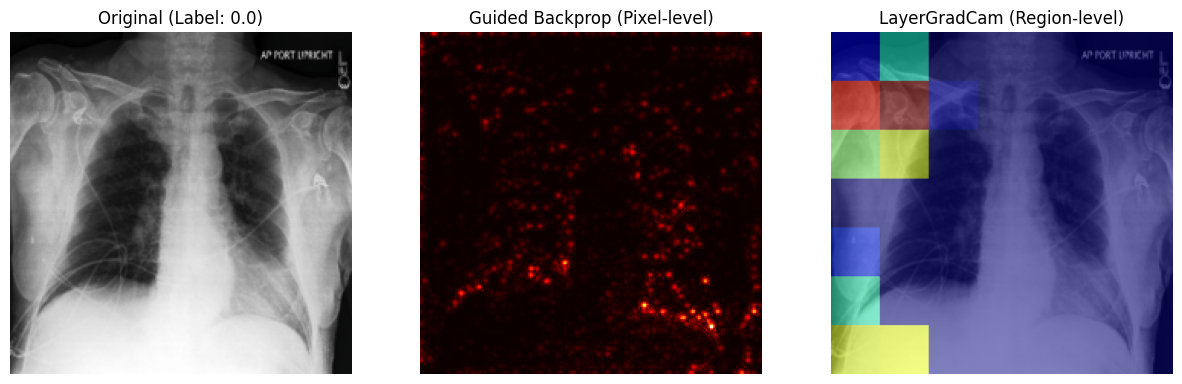

In [ ]:
def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    return np.clip(img, 0, 1)

img_np = denormalize(images[0])

plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.title(f"Original (Label: {labels[0].item()})")
plt.imshow(img_np)
plt.axis('off')

# Guided Backprop
plt.subplot(1,3,2)
plt.title("Guided Backprop (Pixel-level)")
plt.imshow(gbp_map, cmap='hot')
plt.axis('off')

# Grad-CAM
plt.subplot(1,3,3)
plt.title("LayerGradCam (Region-level)")
plt.imshow(img_np)
plt.imshow(gc_map, cmap='jet', alpha=0.5)
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import ndcg_score

# Radiologist ground-truth relevance scores
RADIOLOGIST_SCORES = {
    "Rad_1":  5.5,
    "Rad_2":  5.0,
    "Rad_3":  4.5,
    "Rad_4":  4.0,
    "Rad_5":  3.5,
    "Rad_6":  3.0,
    "Rad_7":  2.5,
    "Rad_8":  2.0,
    "Rad_9":  1.5,
    "Rad_10": 1.0,
}

CATALOG_DIR = "/content/ranking_annotations"  # Directory containing catalog images, in colab you need to upload them first
CATALOG_NAMES = [f"Rad_{i}" for i in range(1, 11)]

print("Radiologist scores:")
for name, score in RADIOLOGIST_SCORES.items():
    print(f"  {name}: {score}")

Radiologist scores:
  Rad_1: 5.5
  Rad_2: 5.0
  Rad_3: 4.5
  Rad_4: 4.0
  Rad_5: 3.5
  Rad_6: 3.0
  Rad_7: 2.5
  Rad_8: 2.0
  Rad_9: 1.5
  Rad_10: 1.0


In [ ]:
# Feature extractor via forward hook on avgpool
_embedding_cache = {}

def _hook_fn(module, input, output):
    _embedding_cache['feat'] = output.squeeze(-1).squeeze(-1)

hook = model.avgpool.register_forward_hook(_hook_fn)

def extract_embedding(img_tensor):
    """
    Args: img_tensor: [1, 3, 224, 224] on any device
    Returns: numpy array of shape (512,)
    """
    model.eval()
    with torch.no_grad():
        _ = model(img_tensor.to(device))
    return _embedding_cache['feat'].squeeze(0).cpu().numpy()

print("Feature extractor hook registered on model.avgpool")

Feature extractor hook registered on model.avgpool


In [ ]:
# Preprocessing transform (same as training)
import torchvision.transforms as transforms

preprocess = transforms.Compose([
    # match input size expected by ResNet-18
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # same as used during training
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def load_image(path):
    """Load a PNG/JPG and return a [1, 3, 224, 224] tensor"""
    img = Image.open(path).convert("RGB")
    return preprocess(img).unsqueeze(0)

# Embed query
query_path = os.path.join(CATALOG_DIR, "test_image.png")
query_emb  = extract_embedding(load_image(query_path))
query_emb  = query_emb / (np.linalg.norm(query_emb) + 1e-8) # L2 normalize to unit vector

print(f"Query embedding shape: {query_emb.shape}")

# Embed catalog, the 10 images
catalog_embeddings = {}
for name in CATALOG_NAMES:
    img_path = os.path.join(CATALOG_DIR, f"{name}.png")
    emb = extract_embedding(load_image(img_path))
    emb = emb / (np.linalg.norm(emb) + 1e-8) # L2 normalize so dot product = cosine similarity
    catalog_embeddings[name] = emb

print(f"Catalog embedded: {len(catalog_embeddings)} images")

Query embedding shape: (512,)
Catalog embedded: 10 images


In [ ]:
# Compute cosine similarities and rank
similarities = {
    name: float(np.dot(query_emb, emb))
    for name, emb in catalog_embeddings.items()
}

# Sort descending by similarity of the model
predicted_ranking = sorted(similarities.items(), key=lambda x: x[1], reverse=True)

print("Predicted ranking (model):")
print(f"  {'Rank':<6} {'Image':<10} {'Similarity':>10}  {'Rad score':>10}")
print("  " + "-" * 42)
for rank, (name, sim) in enumerate(predicted_ranking, 1):
    rad_score = RADIOLOGIST_SCORES[name]
    print(f"  {rank:<6} {name:<10} {sim:>10.4f}  {rad_score:>10.1f}")

Predicted ranking (model):
  Rank   Image      Similarity   Rad score
  ------------------------------------------
  1      Rad_6          0.9363         3.0
  2      Rad_1          0.9297         5.5
  3      Rad_5          0.9164         3.5
  4      Rad_2          0.8936         5.0
  5      Rad_3          0.8767         4.5
  6      Rad_8          0.8323         2.0
  7      Rad_4          0.5731         4.0
  8      Rad_7          0.5269         2.5
  9      Rad_9          0.4944         1.5
  10     Rad_10         0.4552         1.0


In [ ]:
# nDCG evaluation

true_relevance  = np.array([RADIOLOGIST_SCORES[name] for name, _ in predicted_ranking])
ideal_relevance = np.array(sorted(RADIOLOGIST_SCORES.values(), reverse=True))

names = CATALOG_NAMES
y_true  = np.array([RADIOLOGIST_SCORES[n] for n in names])
y_score = np.array([similarities[n] for n in names])

ndcg = ndcg_score(y_true.reshape(1, -1), y_score.reshape(1, -1))

print(f"nDCG score: {ndcg:.4f}")
print()
print("Ideal relevance (radiologist): ", ideal_relevance)
print("True relevance  (our ranking): ", true_relevance)

nDCG score: 0.9093

Ideal relevance (radiologist):  [5.5 5.  4.5 4.  3.5 3.  2.5 2.  1.5 1. ]
True relevance  (our ranking):  [3.  5.5 3.5 5.  4.5 2.  4.  2.5 1.5 1. ]


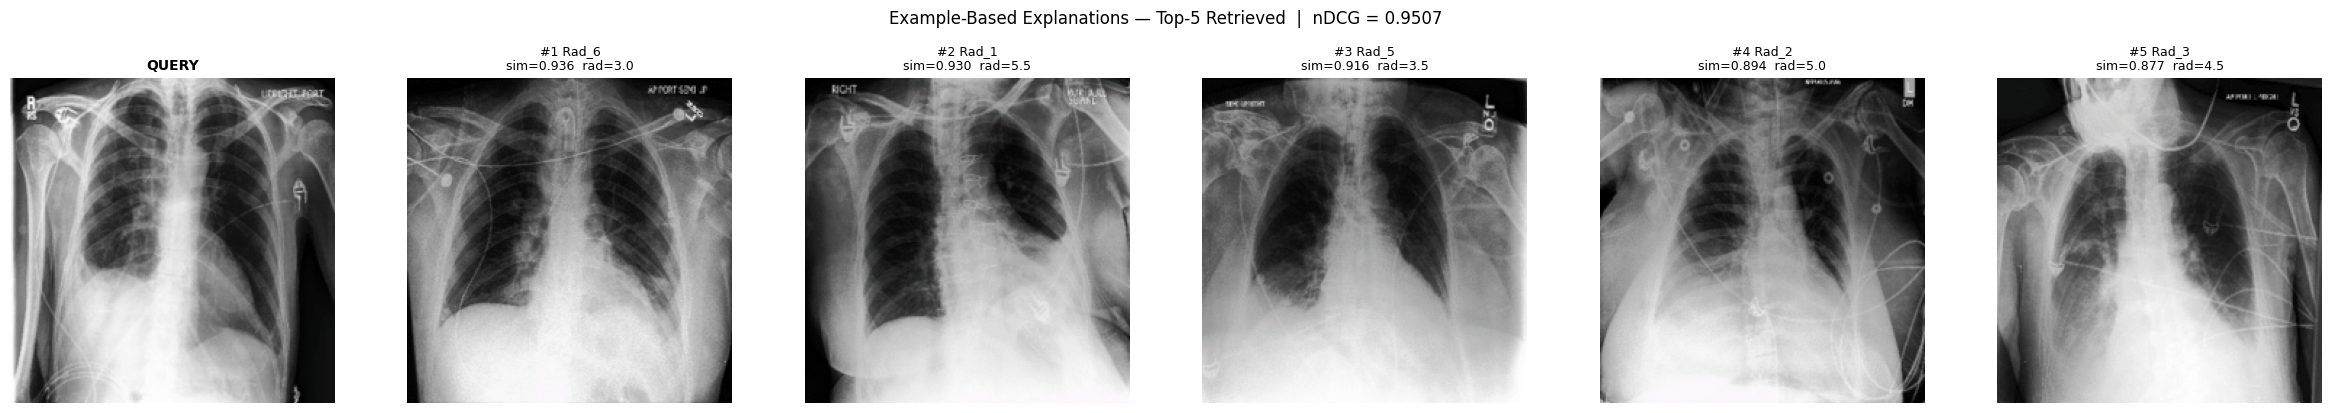

Hook removed.


In [ ]:
# Visualization
def denorm(tensor):
    img = tensor.squeeze(0).permute(1, 2, 0).numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    return np.clip(img, 0, 1)

TOP_K = 5
top_k = predicted_ranking[:TOP_K]

fig, axes = plt.subplots(1, TOP_K + 1, figsize=(4 * (TOP_K + 1), 4))

# Query
axes[0].imshow(denorm(load_image(query_path)))
axes[0].set_title("QUERY", fontsize=10, fontweight='bold')
for spine in axes[0].spines.values():
    spine.set_edgecolor("#006175")
    spine.set_linewidth(3)
axes[0].axis('off')

# Top-k catalog images
for i, (name, sim) in enumerate(top_k):
    img_path = os.path.join(CATALOG_DIR, f"{name}.png")
    axes[i + 1].imshow(denorm(load_image(img_path)))
    rad_score = RADIOLOGIST_SCORES[name]
    # How far is this image's radiologist rank from our rank?
    rad_rank = sorted(RADIOLOGIST_SCORES, key=RADIOLOGIST_SCORES.get, reverse=True).index(name) + 1
    color = "#91D600" if rad_rank <= 3 else ("#FFA500" if rad_rank <= 6 else "#cc0000")
    axes[i + 1].set_title(
        f"#{i+1} {name}\nsim={sim:.3f}  rad={rad_score}", fontsize=9
    )
    for spine in axes[i + 1].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    axes[i + 1].axis('off')

plt.suptitle(f"Example-Based Explanations — Top-{TOP_K} Retrieved  |  nDCG = {ndcg:.4f}",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Remove hook when done
hook.remove()
print("Hook removed.")